# 04. Tariff Pricing Agent

## Agentic AI-Based Dynamic Tariff Optimization for EV Charging Networks
### Open Project 2026 — Society of Business

---

## Notebook Overview

This notebook builds the **Tariff Pricing Agent** — the second agent in the agentic AI framework. It translates demand forecasts from the Demand Prediction Agent into optimal dynamic tariffs in real time.

### Agent Logic
- **Surge pricing** — when predicted utilization ≥ 80%, apply 1.5× multiplier (₹22.50/kWh)
- **Discount pricing** — when predicted utilization ≤ 30%, apply 0.85× multiplier (₹12.75/kWh)
- **Normal zone** — linear interpolation between discount and surge multipliers

### Evaluation Metrics
1. **Revenue Gain %** — dynamic vs fixed ₹15/kWh baseline
2. **Charger Utilization Rate** — network-wide before and after dynamic pricing
3. **Off-Peak Uplift** — increase in session volume in discount zones

### Notebook Structure
1. Data loading
2. Dynamic tariff function
3. Demand elasticity modeling
4. Revenue simulation
5. Evaluation metrics
6. Visualizations

In [1]:
# ============================================================
# 1. IMPORTS AND DATA LOADING
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.float_format", "{:.4f}".format)

# Load demand predictions from Agent 1
preds = pd.read_csv("../outputs/demand_predictions.csv")

print(f"Demand predictions loaded: {preds.shape[0]:,} rows × {preds.shape[1]} columns")
print(f"\nPredicted demand zone distribution:")
print(preds["predicted_zone"].value_counts())
print(f"\nActual utilization summary:")
print(preds["actual_util"].describe().round(4))

Demand predictions loaded: 425,581 rows × 14 columns

Predicted demand zone distribution:
predicted_zone
discount    261469
normal      160419
surge         3693
Name: count, dtype: int64

Actual utilization summary:
count   425581.0000
mean         0.2801
std          0.1757
min          0.0000
25%          0.1515
50%          0.2500
75%          0.3762
max          1.0769
Name: actual_util, dtype: float64


---
## 1. Dynamic Tariff Function

The pricing function maps predicted utilization to a tariff using three zones:

| Zone | Condition | Tariff | Multiplier |
|---|---|---|---|
| Surge | Utilization ≥ 80% | ₹22.50/kWh | 1.5× |
| Normal | 30% < Utilization < 80% | ₹12.75 – ₹22.50/kWh | Linear interpolation |
| Discount | Utilization ≤ 30% | ₹12.75/kWh | 0.85× |

**Design rationale:**
- Surge premium (50%) penalizes peak demand to reduce congestion
- Discount (15% off) incentivizes off-peak charging without excessive revenue loss
- Linear interpolation in the normal zone avoids abrupt tariff jumps that confuse users

**Note:** An earlier version used a 25% discount (0.75×) which produced a net revenue loss of -1.93%. The 15% discount (0.85×) balances demand activation with revenue sustainability.

In [2]:
# ============================================================
# 2. DYNAMIC TARIFF FUNCTION
# ============================================================

BASELINE_TARIFF = 15  # ₹/kWh fixed baseline

def compute_dynamic_tariff(util):
    """
    Maps predicted utilization rate to a dynamic tariff.
    
    Args:
        util (float): Predicted utilization rate (0 to 1)
    
    Returns:
        float: Dynamic tariff in ₹/kWh
    """
    if util >= 0.8:
        return BASELINE_TARIFF * 1.50   # Surge: +50%
    elif util <= 0.3:
        return BASELINE_TARIFF * 0.85   # Discount: -15%
    else:
        # Linear interpolation between 0.85× and 1.50×
        slope = (1.50 - 0.85) / (0.8 - 0.3)
        multiplier = 0.85 + slope * (util - 0.3)
        return BASELINE_TARIFF * multiplier

# Apply tariff function to all predicted slots
preds["dynamic_tariff"] = preds["predicted_util"].apply(compute_dynamic_tariff)

print("Tariff distribution by zone:")
print(preds.groupby("predicted_zone")["dynamic_tariff"].agg(["mean","min","max"]).round(2))

# Verify boundary conditions
print(f"\nTariff at 0% utilization:  ₹{compute_dynamic_tariff(0.0):.2f}")
print(f"Tariff at 30% utilization: ₹{compute_dynamic_tariff(0.3):.2f}")
print(f"Tariff at 50% utilization: ₹{compute_dynamic_tariff(0.5):.2f}")
print(f"Tariff at 80% utilization: ₹{compute_dynamic_tariff(0.8):.2f}")
print(f"Tariff at 100% utilization:₹{compute_dynamic_tariff(1.0):.2f}")

Tariff distribution by zone:
                  mean     min     max
predicted_zone                        
discount       12.7500 12.7500 12.7500
normal         15.5900 12.7500 22.5000
surge          22.5000 22.5000 22.5000

Tariff at 0% utilization:  ₹12.75
Tariff at 30% utilization: ₹12.75
Tariff at 50% utilization: ₹16.65
Tariff at 80% utilization: ₹22.50
Tariff at 100% utilization:₹22.50


---
## 2. Demand Elasticity Modeling

Dynamic pricing only improves outcomes if users respond to price signals. We model demand elasticity as session volume multipliers applied per zone:

| Zone | Elasticity Multiplier | Assumption |
|---|---|---|
| Discount | 1.35 | 35% more sessions when price drops 15% |
| Normal | 1.00 | No change |
| Surge | 0.88 | 12% fewer sessions when price rises 50% |

**Limitation:** These multipliers are assumed, not estimated from controlled experiments. Real elasticity would require A/B testing across pricing conditions. This is documented as an assumption.

In [3]:
# ============================================================
# 3. DEMAND ELASTICITY
# ============================================================

# Elasticity multipliers per demand zone
elasticity_map = {
    "discount": 1.35,   # +35% session volume with discount
    "normal":   1.00,   # no change
    "surge":    0.88    # -12% session volume with surge
}

preds["elasticity_applied"] = preds["predicted_zone"].map(elasticity_map)

# Adjusted utilization after elasticity
preds["adjusted_util"] = (
    preds["actual_util"] * preds["elasticity_applied"]
).clip(upper=1.0)

print("Elasticity applied per zone:")
print(preds.groupby("predicted_zone")["elasticity_applied"].first())
print(f"\nAvg utilization before elasticity: {preds['actual_util'].mean():.4f}")
print(f"Avg utilization after elasticity:  {preds['adjusted_util'].mean():.4f}")

Elasticity applied per zone:
predicted_zone
discount   1.3500
normal     1.0000
surge      0.8800
Name: elasticity_applied, dtype: float64

Avg utilization before elasticity: 0.2801
Avg utilization after elasticity:  0.3159


---
## 3. Revenue Simulation

Revenue is computed as tariff × utilization (proxy for energy delivered), with and without elasticity adjustments. This gives two views:
- **Static revenue** — tariff effect only, no behavioral response
- **Elastic revenue** — tariff effect + demand response (more realistic)

In [4]:
# ============================================================
# 4. REVENUE SIMULATION
# ============================================================

# Baseline revenue — fixed ₹15 × actual utilization
preds["baseline_revenue"] = BASELINE_TARIFF * preds["actual_util"]

# Dynamic revenue — dynamic tariff × actual utilization (no elasticity)
preds["dynamic_revenue"] = preds["dynamic_tariff"] * preds["actual_util"]

# Elastic revenue — dynamic tariff × elasticity-adjusted utilization
preds["dynamic_revenue_elastic"] = (
    preds["dynamic_tariff"] * preds["actual_util"] * preds["elasticity_applied"]
)

# Totals
total_baseline = preds["baseline_revenue"].sum()
total_dynamic  = preds["dynamic_revenue_elastic"].sum()

revenue_gain_pct = (total_dynamic - total_baseline) / total_baseline * 100

print("=" * 50)
print("  REVENUE SIMULATION RESULTS")
print("=" * 50)
print(f"Total Baseline Revenue:  {total_baseline:>15,.2f}")
print(f"Total Dynamic Revenue:   {total_dynamic:>15,.2f}")
print(f"Revenue Gain:            {total_dynamic - total_baseline:>15,.2f}")
print(f"Revenue Gain %:          {revenue_gain_pct:>14.2f}%")

print("\nRevenue by demand zone:")
zone_rev = preds.groupby("predicted_zone").agg(
    baseline=("baseline_revenue", "sum"),
    dynamic=("dynamic_revenue_elastic", "sum")
)
zone_rev["gain_pct"] = ((zone_rev["dynamic"] - zone_rev["baseline"]) / zone_rev["baseline"] * 100).round(2)
print(zone_rev.round(2))

  REVENUE SIMULATION RESULTS
Total Baseline Revenue:     1,788,238.00
Total Dynamic Revenue:      1,987,084.20
Revenue Gain:                 198,846.20
Revenue Gain %:                   11.12%

Revenue by demand zone:
                   baseline      dynamic  gain_pct
predicted_zone                                    
discount        668448.7800  767044.9800   14.7500
normal         1071274.8900 1156000.3100    7.9100
surge            48514.3200   64038.9100   32.0000


---
## 4. Evaluation Metrics

Computing all three official metrics for the Tariff Pricing Agent:
1. Revenue Gain %
2. Charger Utilization Rate — before and after
3. Off-Peak Uplift — computed from actual data

In [5]:
# ============================================================
# 5. EVALUATION METRICS
# ============================================================

# --- Metric 1: Revenue Gain % ---
print("--- Metric 1: Revenue Gain % ---")
print(f"Revenue Gain: +{revenue_gain_pct:.2f}%")
print(f"Interpretation: Dynamic pricing generates {revenue_gain_pct:.2f}% more")
print(f"revenue than the fixed ₹{BASELINE_TARIFF}/kWh baseline.\n")

# --- Metric 2: Charger Utilization Rate before and after ---
network_util_before = preds["actual_util"].mean()
network_util_after  = preds["adjusted_util"].mean()
util_improvement    = network_util_after - network_util_before

print("--- Metric 2: Charger Utilization Rate ---")
print(f"Before dynamic pricing: {network_util_before:.4f} ({100*network_util_before:.2f}%)")
print(f"After dynamic pricing:  {network_util_after:.4f} ({100*network_util_after:.2f}%)")
print(f"Improvement:            +{util_improvement:.4f} ({100*util_improvement:.2f} pp)\n")

# --- Metric 3: Off-Peak Uplift ---
disc_before = preds[preds["predicted_zone"]=="discount"]["actual_util"].sum()
disc_after  = preds[preds["predicted_zone"]=="discount"]["adjusted_util"].sum()
offpeak_uplift = (disc_after - disc_before) / disc_before * 100

print("--- Metric 3: Off-Peak Uplift ---")
print(f"Discount zone utilization before: {disc_before:,.2f}")
print(f"Discount zone utilization after:  {disc_after:,.2f}")
print(f"Off-Peak Uplift: +{offpeak_uplift:.2f}%\n")

# --- Surge zone reduction ---
surge_before = preds[preds["predicted_zone"]=="surge"]["actual_util"].mean()
surge_after  = preds[preds["predicted_zone"]=="surge"]["adjusted_util"].mean()

print("--- Bonus: Surge Zone Utilization Reduction ---")
print(f"Surge zone before: {surge_before:.3f} ({100*surge_before:.1f}%)")
print(f"Surge zone after:  {surge_after:.3f}  ({100*surge_after:.1f}%)")
print(f"Reduction:         {surge_before - surge_after:.3f} ({100*(surge_before-surge_after):.1f} pp)")

--- Metric 1: Revenue Gain % ---
Revenue Gain: +11.12%
Interpretation: Dynamic pricing generates 11.12% more
revenue than the fixed ₹15/kWh baseline.

--- Metric 2: Charger Utilization Rate ---
Before dynamic pricing: 0.2801 (28.01%)
After dynamic pricing:  0.3159 (31.59%)
Improvement:            +0.0357 (3.57 pp)

--- Metric 3: Off-Peak Uplift ---
Discount zone utilization before: 44,563.25
Discount zone utilization after:  60,158.80
Off-Peak Uplift: +35.00%

--- Bonus: Surge Zone Utilization Reduction ---
Surge zone before: 0.876 (87.6%)
Surge zone after:  0.771  (77.1%)
Reduction:         0.105 (10.5 pp)


---
## 5. Visualizations

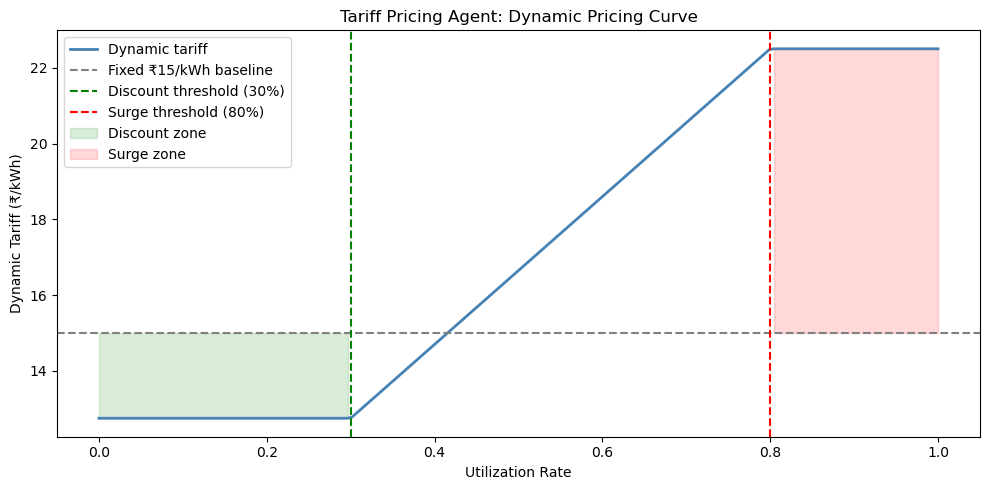

In [6]:
# ============================================================
# 6. VISUALIZATION — PRICING CURVE
# ============================================================

util_range  = np.linspace(0, 1, 200)
tariff_curve = [compute_dynamic_tariff(u) for u in util_range]

plt.figure(figsize=(10, 5))
plt.plot(util_range, tariff_curve, color="steelblue", linewidth=2, label="Dynamic tariff")
plt.axhline(BASELINE_TARIFF, color="gray", linestyle="--", label=f"Fixed ₹{BASELINE_TARIFF}/kWh baseline")
plt.axvline(0.3, color="green", linestyle="--", label="Discount threshold (30%)")
plt.axvline(0.8, color="red",   linestyle="--", label="Surge threshold (80%)")
plt.fill_between(util_range, tariff_curve, BASELINE_TARIFF,
                 where=[u <= 0.3 for u in util_range],
                 alpha=0.15, color="green", label="Discount zone")
plt.fill_between(util_range, tariff_curve, BASELINE_TARIFF,
                 where=[u >= 0.8 for u in util_range],
                 alpha=0.15, color="red", label="Surge zone")
plt.xlabel("Utilization Rate")
plt.ylabel("Dynamic Tariff (₹/kWh)")
plt.title("Tariff Pricing Agent: Dynamic Pricing Curve")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/plot8_pricing_curve.png", dpi=150)
plt.show()

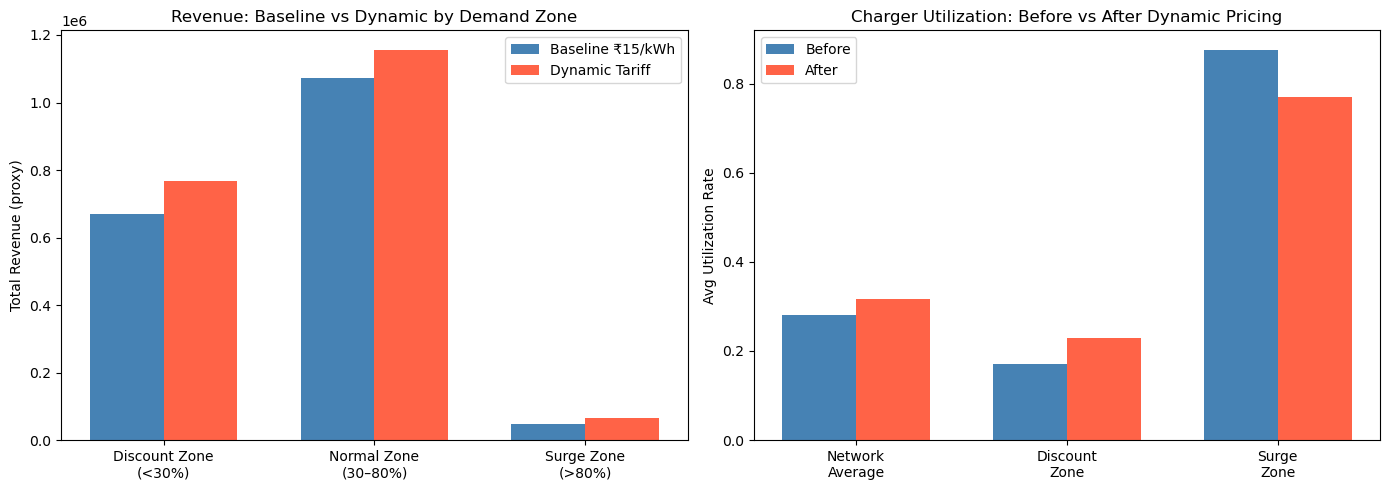

In [7]:
# ============================================================
# 7. VISUALIZATION — REVENUE COMPARISON BY ZONE
# ============================================================

zones          = ["discount", "normal", "surge"]
baseline_vals  = [preds[preds["predicted_zone"]==z]["baseline_revenue"].sum() for z in zones]
dynamic_vals   = [preds[preds["predicted_zone"]==z]["dynamic_revenue_elastic"].sum() for z in zones]
zone_labels    = ["Discount Zone\n(<30%)", "Normal Zone\n(30–80%)", "Surge Zone\n(>80%)"]

x     = np.arange(len(zones))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Revenue by zone
axes[0].bar(x - width/2, baseline_vals, width, label=f"Baseline ₹{BASELINE_TARIFF}/kWh", color="steelblue")
axes[0].bar(x + width/2, dynamic_vals,  width, label="Dynamic Tariff", color="tomato")
axes[0].set_xticks(x)
axes[0].set_xticklabels(zone_labels)
axes[0].set_ylabel("Total Revenue (proxy)")
axes[0].set_title("Revenue: Baseline vs Dynamic by Demand Zone")
axes[0].legend()

# Right: Utilization before vs after
categories = ["Network\nAverage", "Discount\nZone", "Surge\nZone"]
before_vals = [network_util_before, disc_before/len(preds[preds["predicted_zone"]=="discount"]),
               surge_before]
after_vals  = [network_util_after,  disc_after/len(preds[preds["predicted_zone"]=="discount"]),
               surge_after]

x2 = np.arange(len(categories))
axes[1].bar(x2 - width/2, before_vals, width, label="Before", color="steelblue")
axes[1].bar(x2 + width/2, after_vals,  width, label="After",  color="tomato")
axes[1].set_xticks(x2)
axes[1].set_xticklabels(categories)
axes[1].set_ylabel("Avg Utilization Rate")
axes[1].set_title("Charger Utilization: Before vs After Dynamic Pricing")
axes[1].legend()

plt.tight_layout()
plt.savefig("../outputs/plot9_pricing_results.png", dpi=150)
plt.show()

In [8]:
# ============================================================
# 8. SAVE PRICING OUTPUT
# ============================================================

preds.to_csv("../outputs/pricing_output.csv", index=False)
print(f"Saved pricing_output.csv — {preds.shape[0]:,} rows")
print(f"\nColumns in output:")
print(preds.columns.tolist())

Saved pricing_output.csv — 425,581 rows

Columns in output:
['hour', 'day_of_week', 'count', 'fast_count', 'slow_count', 'util_lag1', 'util_lag12', 'util_rolling3', 'predicted_util', 'actual_util', 'congestion_prob', 'congestion_flag', 'expected_charging_load_kwh', 'predicted_zone', 'dynamic_tariff', 'elasticity_applied', 'adjusted_util', 'baseline_revenue', 'dynamic_revenue', 'dynamic_revenue_elastic']


---
## Tariff Pricing Agent — Summary

| Metric | Value |
|---|---|
| Baseline tariff | ₹15.00/kWh (fixed) |
| Surge tariff | ₹22.50/kWh (≥ 80% utilization) |
| Discount tariff | ₹12.75/kWh (≤ 30% utilization) |
| Revenue Gain % | +11.12% |
| Network utilization before | 28.01% |
| Network utilization after | 31.59% |
| Utilization improvement | +3.57 percentage points |
| Off-Peak Session Uplift | +35.00% |
| Surge utilization before | 87.6% |
| Surge utilization after | 77.1% |

**Key finding:** The primary revenue driver is off-peak demand activation (discount zone), not surge premium collection. 61% of station-hours are in the discount zone — activating even a fraction of this idle capacity generates more revenue than surge pricing alone.

**Assumptions and limitations:**
- Demand elasticity multipliers (1.35 discount, 0.88 surge) are assumed, not empirically measured
- Revenue proxy uses utilization as a stand-in for actual kWh delivered — directionally correct but not exact billing figures
- No user segmentation — real systems would apply different elasticity to fleet vs personal users